Pradeep Manikandan D 24BAD088


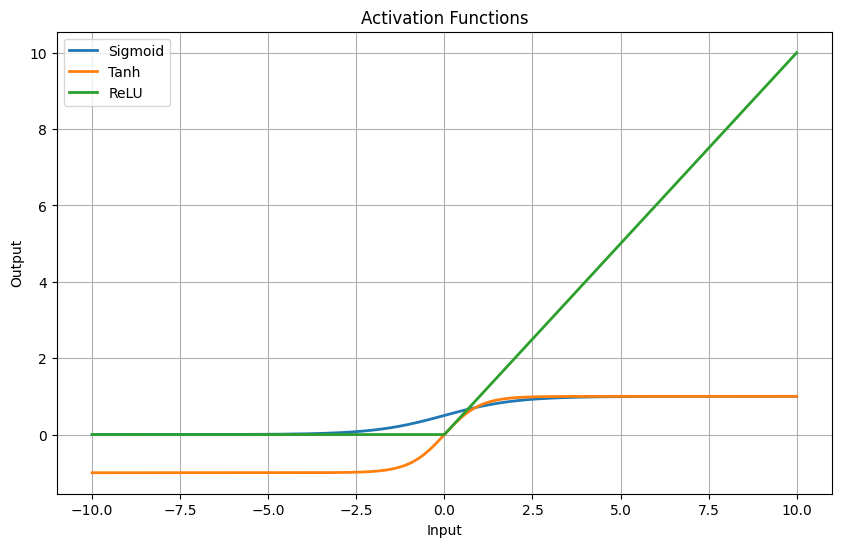

In [ ]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
# Input values
x = np.linspace(-10, 10, 500)

# Activation Functions
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

# Plot
plt.figure(figsize=(10,6))
plt.plot(x, sigmoid, label='Sigmoid', linewidth=2)
plt.plot(x, tanh, label='Tanh', linewidth=2)
plt.plot(x, relu, label='ReLU', linewidth=2)

plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True)
plt.show()

Performance Comparison of Activation Functions


In [ ]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target
# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
# Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

function to build an ANN

In [3]:
def build_model(activation):

    model = Sequential()

    model.add(Dense(32,
                    activation=activation,
                    input_shape=(30,)))

    model.add(Dense(16,
                    activation=activation))

    model.add(Dense(1,
                    activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

Train using Sigmoid, Tanh and ReLU


In [ ]:
activations = ['sigmoid', 'tanh', 'relu']
history_dict = {}
for act in activations:
    print("\nTraining with", act)
    model = build_model(act)
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=30,
        batch_size=32,
        verbose=0
    )
    history_dict[act] = history


Training with sigmoid


c:\Users\PRADEEP MANIKANDAN D\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with tanh

Training with relu


Accuracy Graph

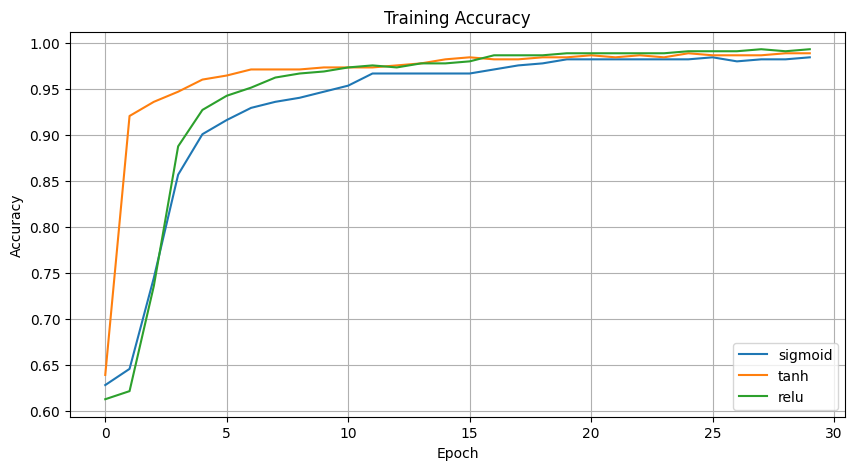

In [ ]:
plt.figure(figsize=(10,5))
for act in activations:
    plt.plot(history_dict[act].history['accuracy'], label=act)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Validation Accuracy

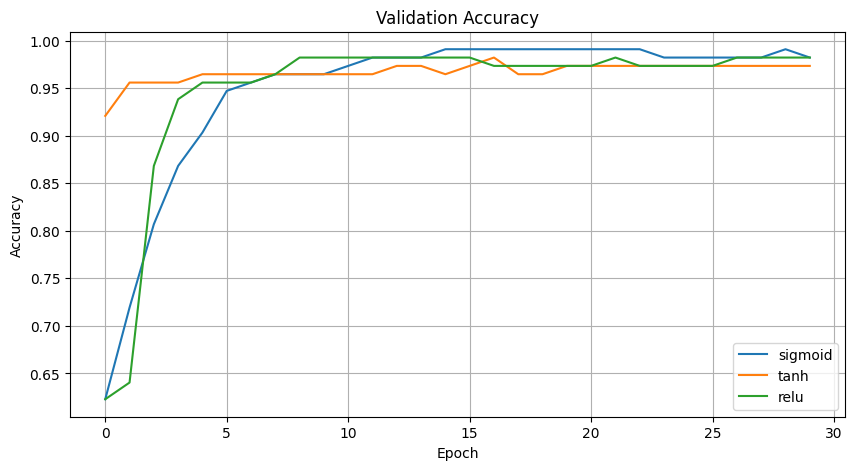

In [ ]:
plt.figure(figsize=(10,5))
for act in activations:
    plt.plot(history_dict[act].history['val_accuracy'], label=act)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Training Loss

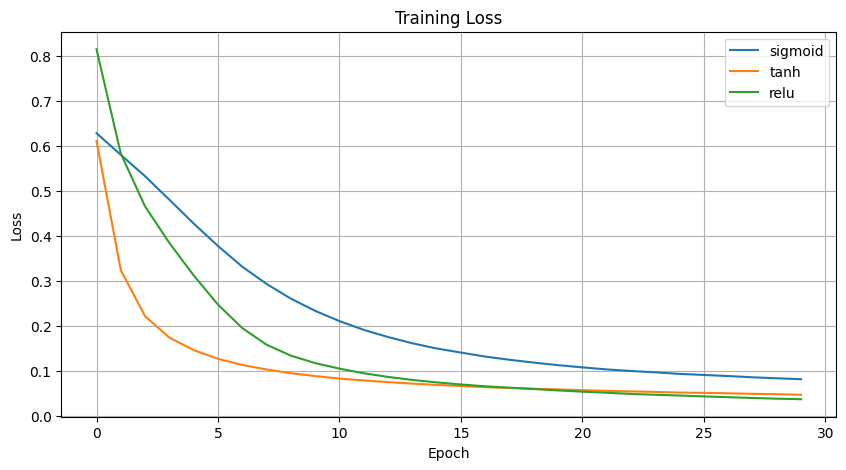

In [ ]:
plt.figure(figsize=(10,5))
for act in activations:
    plt.plot(history_dict[act].history['loss'], label=act)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Validation Loss

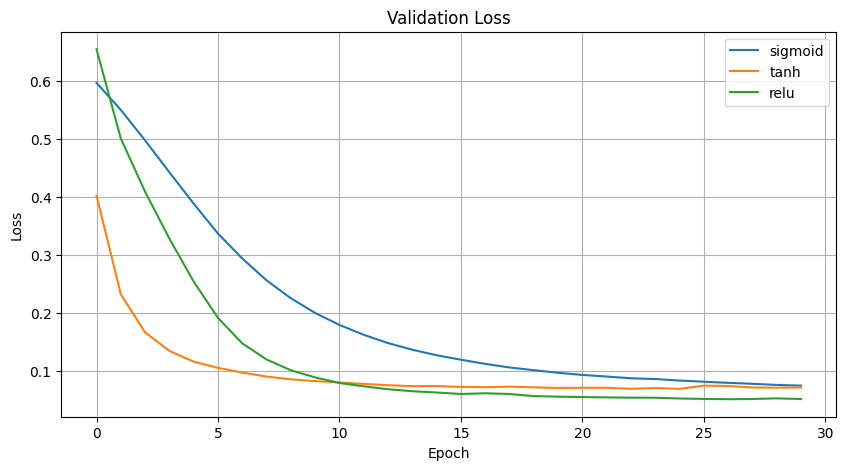

In [ ]:
plt.figure(figsize=(10,5))
for act in activations:
    plt.plot(history_dict[act].history['val_loss'], label=act)
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Final Results

In [ ]:
print("\nFinal Results")
for act in activations:
    print("\nActivation:", act)
    print("Training Accuracy:",
          round(history_dict[act].history['accuracy'][-1],4))
    print("Validation Accuracy:",
          round(history_dict[act].history['val_accuracy'][-1],4))
    print("Training Loss:",
          round(history_dict[act].history['loss'][-1],4))
    print("Validation Loss:",
          round(history_dict[act].history['val_loss'][-1],4))


Final Results

Activation: sigmoid
Training Accuracy: 0.9846
Validation Accuracy: 0.9825
Training Loss: 0.081
Validation Loss: 0.0746

Activation: tanh
Training Accuracy: 0.989
Validation Accuracy: 0.9737
Training Loss: 0.0464
Validation Loss: 0.0713

Activation: relu
Training Accuracy: 0.9934
Validation Accuracy: 0.9825
Training Loss: 0.0366
Validation Loss: 0.0515


Comparison of Optimization Algorithms

In [10]:
def optimizer_model(opt):

    model = Sequential()

    model.add(Dense(32,
                    activation='relu',
                    input_shape=(30,)))

    model.add(Dense(16,
                    activation='relu'))

    model.add(Dense(1,
                    activation='sigmoid'))

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
optimizers = {
    'SGD': tf.keras.optimizers.SGD(),
    'Momentum': tf.keras.optimizers.SGD(momentum=0.9),
    'RMSProp': tf.keras.optimizers.RMSprop(),
    'Adam': tf.keras.optimizers.Adam()
}
optimizer_history = {}

In [ ]:
for name, opt in optimizers.items():
    print("\nTraining using", name)
    model = optimizer_model(opt)
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=30,
        batch_size=32,
        verbose=0
    )
    optimizer_history[name] = history


Training using SGD

Training using Momentum

Training using RMSProp

Training using Adam


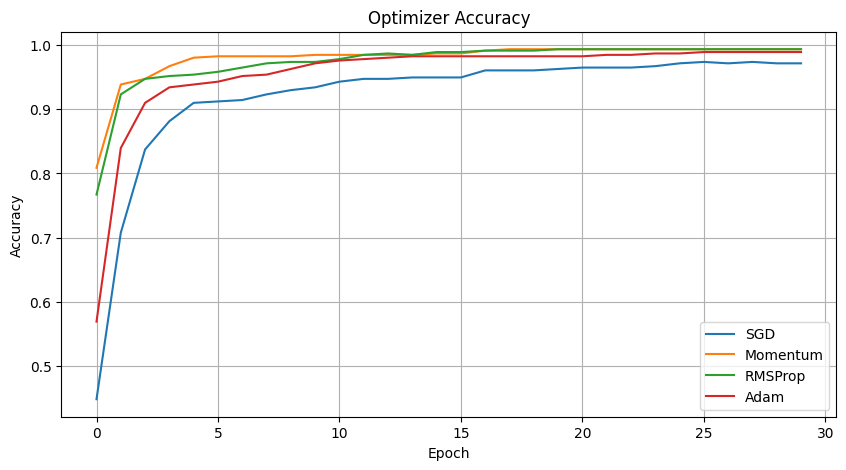

In [13]:
plt.figure(figsize=(10,5))

for name in optimizer_history:
    plt.plot(
        optimizer_history[name].history['accuracy'],
        label=name
    )

plt.title("Optimizer Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

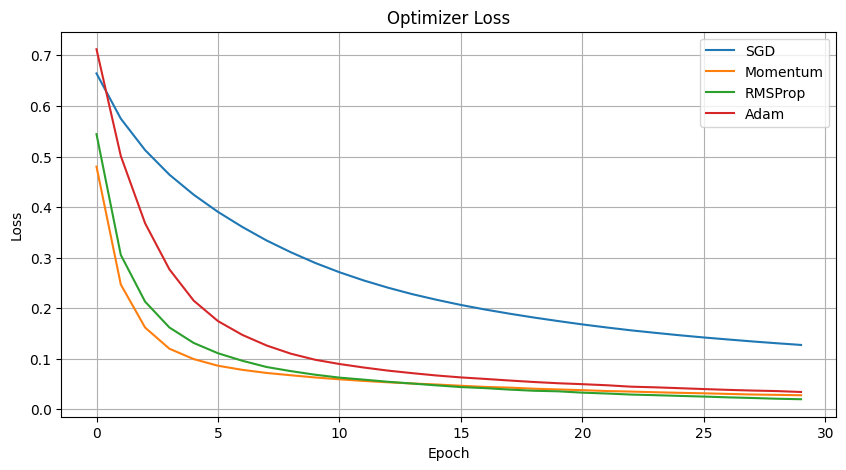

In [ ]:
plt.figure(figsize=(10,5))
for name in optimizer_history:
    plt.plot(
        optimizer_history[name].history['loss'],
        label=name
    )
plt.title("Optimizer Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

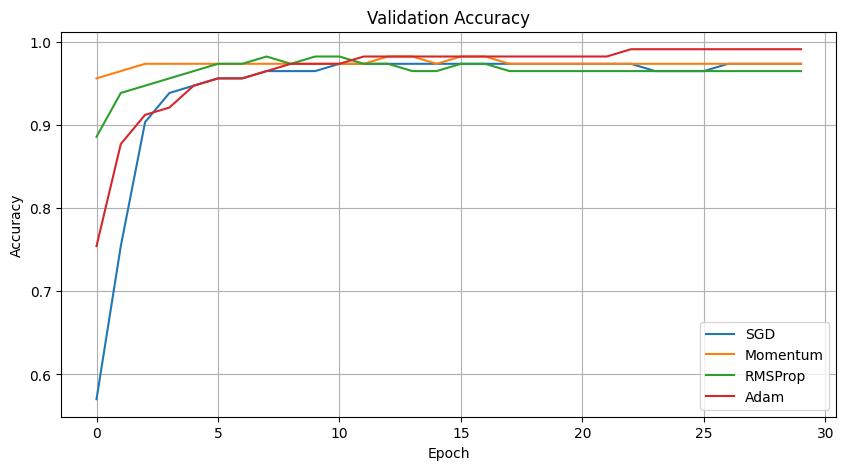

In [ ]:
plt.figure(figsize=(10,5))
for name in optimizer_history:
    plt.plot(
        optimizer_history[name].history['val_accuracy'],
        label=name
    )
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

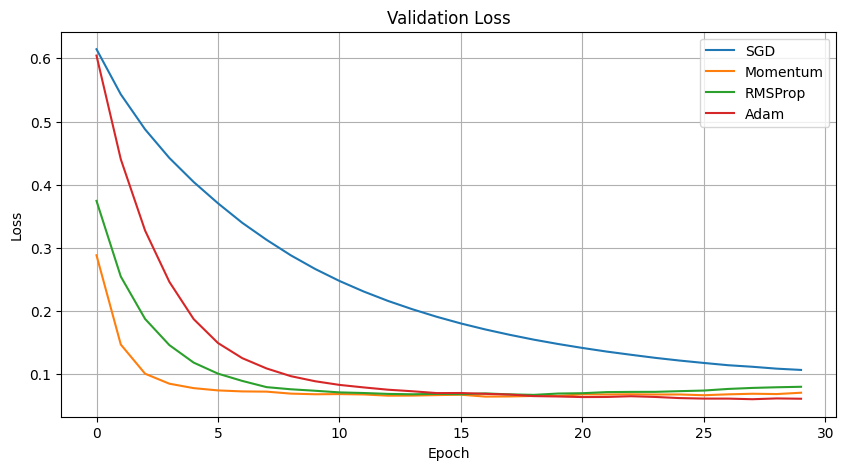

In [ ]:
plt.figure(figsize=(10,5))
for name in optimizer_history:
    plt.plot(
        optimizer_history[name].history['val_loss'],
        label=name
    )
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
print("\nOptimizer Comparison")

for name in optimizer_history:

    print("\nOptimizer:", name)

    print("Training Accuracy:",
          round(optimizer_history[name].history['accuracy'][-1],4))

    print("Validation Accuracy:",
          round(optimizer_history[name].history['val_accuracy'][-1],4))

    print("Training Loss:",
          round(optimizer_history[name].history['loss'][-1],4))

    print("Validation Loss:",
          round(optimizer_history[name].history['val_loss'][-1],4))


Optimizer Comparison

Optimizer: SGD
Training Accuracy: 0.9714
Validation Accuracy: 0.9737
Training Loss: 0.1274
Validation Loss: 0.107

Optimizer: Momentum
Training Accuracy: 0.9934
Validation Accuracy: 0.9737
Training Loss: 0.028
Validation Loss: 0.071

Optimizer: RMSProp
Training Accuracy: 0.9934
Validation Accuracy: 0.9649
Training Loss: 0.0201
Validation Loss: 0.0804

Optimizer: Adam
Training Accuracy: 0.989
Validation Accuracy: 0.9912
Training Loss: 0.0344
Validation Loss: 0.0614
